In [33]:
# Import Basic Packgaes 
import numpy as np
import pandas as pd
from datetime import datetime
import statsmodels as sm
import scipy
import itertools
import glob

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

In [34]:
df = pd.read_csv('C:\\Users\\11035628\\Documents\\P1_700_800\\p1_lt_2023_05_23_clean.csv')
df.head()

,Time,P1-CPM,P1-Water Suction Pressure,P1-Water Discharge Pressure,P1-Air-Supply-pressure,P1-Water Suction Flowrate,P1-Water Discharge Flowrate,P1-Air Supply Flowrate
0,2023-05-23 00:00:00.010,62.732479,7.709594,11.979158,102.478426,85.645934,88.859789,82.009120
1,2023-05-23 00:00:00.018,62.732479,6.691688,9.807736,108.782554,85.385351,88.772928,81.878790
2,2023-05-23 00:00:00.049,62.732479,15.918216,58.979939,112.915261,85.732795,88.772928,82.204616
3,2023-05-23 00:00:00.079,62.732479,8.942288,44.270305,98.415765,85.559073,88.686067,82.139451
4,2023-05-23 00:00:00.109,62.732479,7.929051,52.675810,101.217600,85.559073,88.686067,81.878790


In [35]:
df.Time = pd.to_datetime(df.Time)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2669876 entries, 0 to 2669875
Data columns (total 8 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   Time                         datetime64[ns]
 1   P1-CPM                       float64       
 2   P1-Water Suction Pressure    float64       
 3   P1-Water Discharge Pressure  float64       
 4   P1-Air-Supply-pressure       float64       
 5   P1-Water Suction Flowrate    float64       
 6   P1-Water Discharge Flowrate  float64       
 7   P1-Air Supply Flowrate       float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 163.0 MB


In [12]:
df.set_index(['Time'], inplace=True)
df.head()

,P1-CPM,P1-Water Suction Pressure,P1-Water Discharge Pressure,P1-Air-Supply-pressure,P1-Water Suction Flowrate,P1-Water Discharge Flowrate,P1-Air Supply Flowrate
Time,,,,,,,
2023-05-23 00:00:00.010,62.732479,7.709594,11.979158,102.478426,85.645934,88.859789,82.009120
2023-05-23 00:00:00.018,62.732479,6.691688,9.807736,108.782554,85.385351,88.772928,81.878790
2023-05-23 00:00:00.049,62.732479,15.918216,58.979939,112.915261,85.732795,88.772928,82.204616
2023-05-23 00:00:00.079,62.732479,8.942288,44.270305,98.415765,85.559073,88.686067,82.139451
2023-05-23 00:00:00.109,62.732479,7.929051,52.675810,101.217600,85.559073,88.686067,81.878790


In [36]:
df.drop(labels='Time', inplace=True, axis=1)
df.head()

,P1-CPM,P1-Water Suction Pressure,P1-Water Discharge Pressure,P1-Air-Supply-pressure,P1-Water Suction Flowrate,P1-Water Discharge Flowrate,P1-Air Supply Flowrate
0,62.732479,7.709594,11.979158,102.478426,85.645934,88.859789,82.009120
1,62.732479,6.691688,9.807736,108.782554,85.385351,88.772928,81.878790
2,62.732479,15.918216,58.979939,112.915261,85.732795,88.772928,82.204616
3,62.732479,8.942288,44.270305,98.415765,85.559073,88.686067,82.139451
4,62.732479,7.929051,52.675810,101.217600,85.559073,88.686067,81.878790


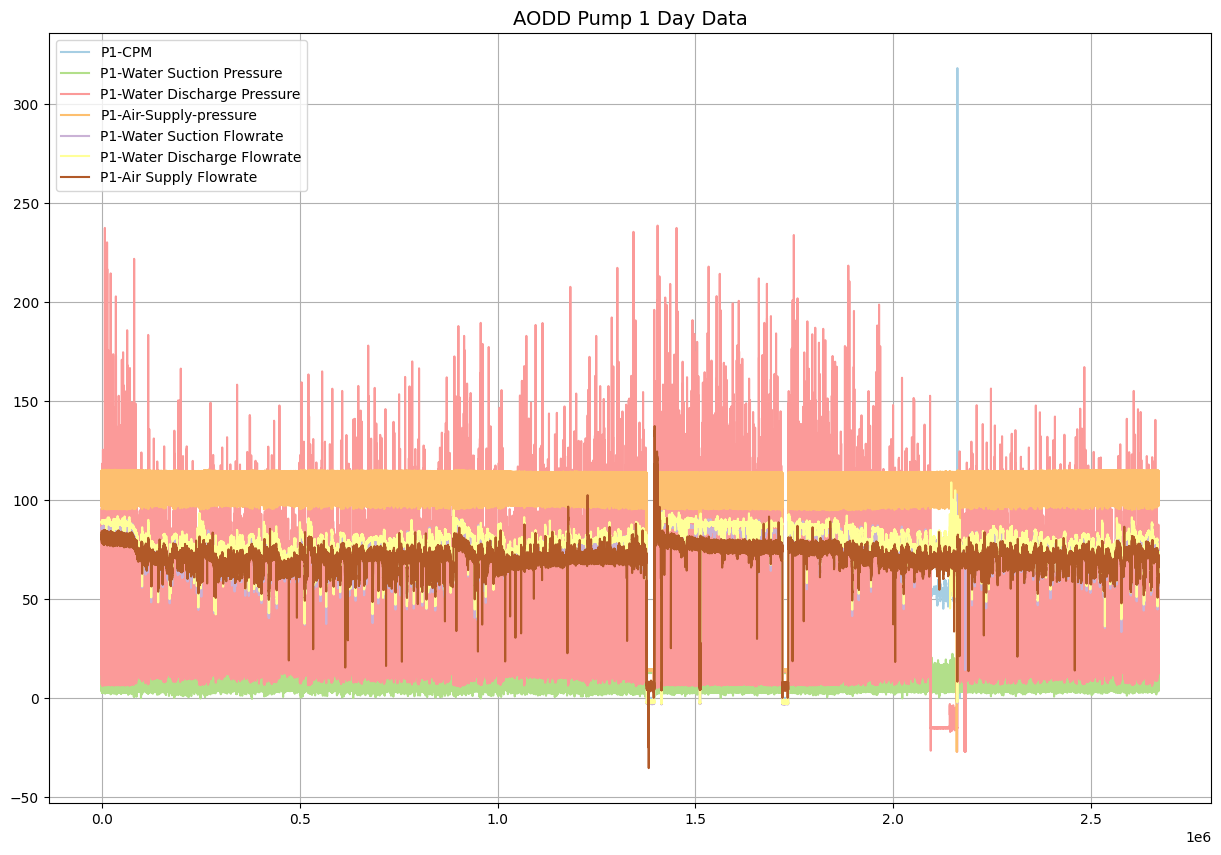

In [38]:
plt.rcParams['figure.figsize'] = 15,10
df.plot(colormap='Paired')
plt.title('AODD Pump 1 Day Data', size=14)
plt.grid()

In [39]:
df.loc[df['P1-Air-Supply-pressure'] < 95]

,P1-CPM,P1-Water Suction Pressure,P1-Water Discharge Pressure,P1-Air-Supply-pressure,P1-Water Suction Flowrate,P1-Water Discharge Flowrate,P1-Air Supply Flowrate
1376663,56.330030,7.312704,42.449113,94.493196,78.870780,81.476608,70.800712
1376664,56.330030,6.075341,38.806727,88.189068,78.870780,81.476608,71.126538
1376665,56.330030,7.812319,35.164342,85.807508,78.870780,81.476608,70.735547
1376666,56.330030,6.925153,32.572645,83.916269,78.957641,81.389748,70.865877
1376667,56.330030,8.582753,28.930259,81.814893,78.957641,81.650330,71.191703
...,...,...,...,...,...,...,...
2167145,55.092089,12.752434,14.710947,23.886956,56.634377,65.754777,47.667078
2167146,55.092089,12.939205,14.710947,23.676819,55.765768,65.581055,47.536748
2167147,0.000000,12.939205,14.710947,23.676819,55.765768,65.581055,47.536748
2167148,66.329187,12.939205,14.710947,23.676819,55.765768,65.581055,47.536748


In [40]:
df = df[df['P1-Air-Supply-pressure'] > 95]

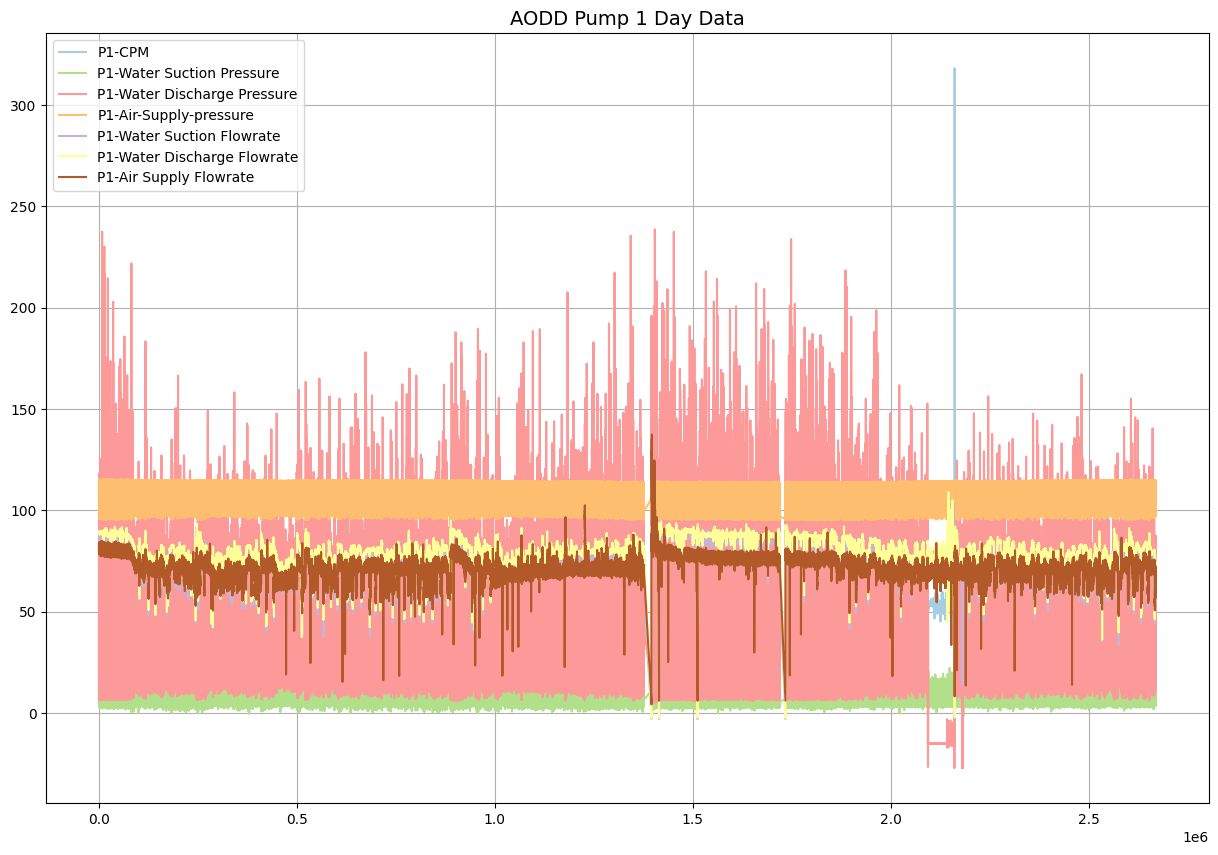

In [41]:
plt.rcParams['figure.figsize'] = 15,10
df.plot(colormap='Paired')
plt.title('AODD Pump 1 Day Data', size=14)
plt.grid()

In [42]:
df.reset_index(inplace=True, drop=True)

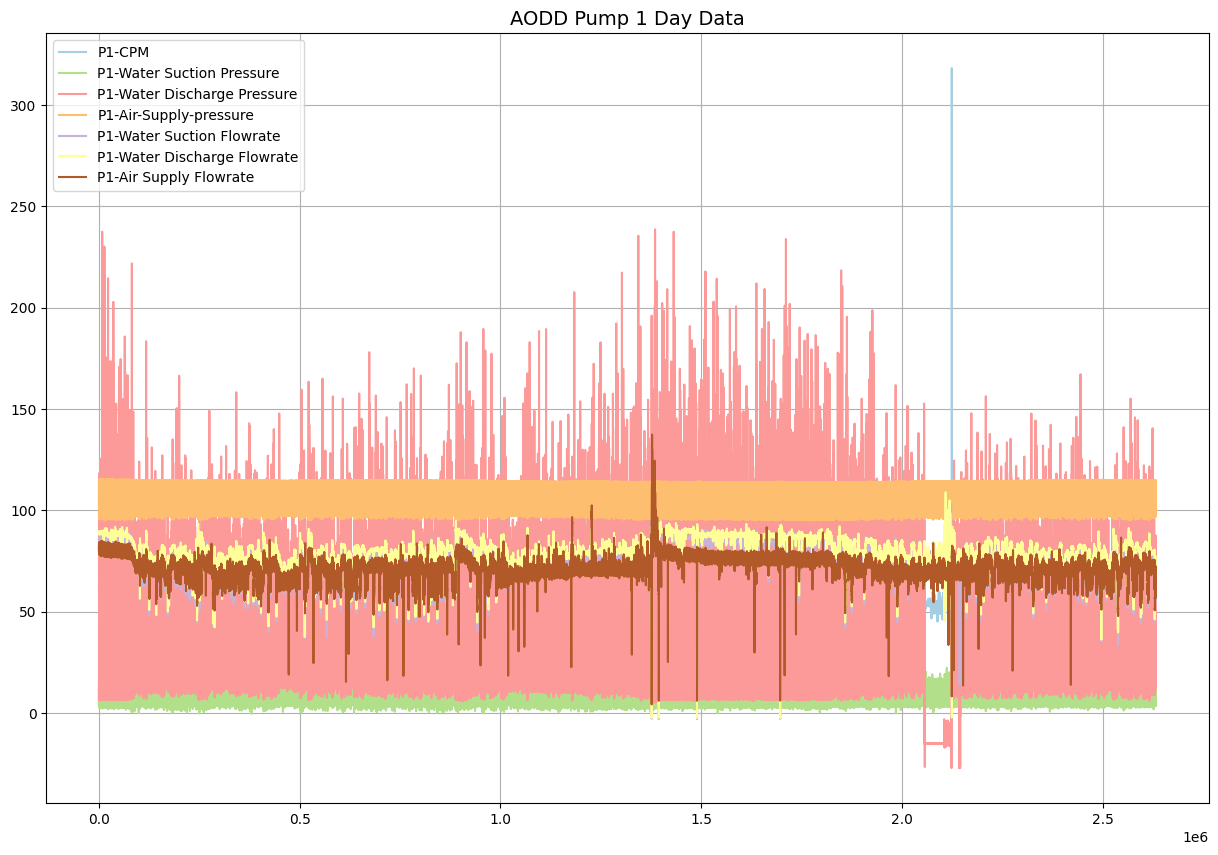

In [43]:
plt.rcParams['figure.figsize'] = 15,10
df.plot(colormap='Paired')
plt.title('AODD Pump 1 Day Data', size=14)
plt.grid()